In [ ]:
'''
Author: Niscienc 60505912+2099193635@users.noreply.github.com
Date: 2026-03-17 20:08:08
LastEditors: Niscienc 60505912+2099193635@users.noreply.github.com
LastEditTime: 2026-03-20 16:33:19
FilePath: \VTCM_PYTHON\analyze_results.ipynb
Description: 

Copyright (c) 2026 by ${git_name_email}, All Rights Reserved. 
'''
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

file_path = Path(r"results\default_project\高速客车-外部导入-vehicle-standard-20260319_215206\files\simulation_result.npz")
input_path = Path(r"results\default_project\高速客车-外部导入-vehicle-standard-20260319_215206\files\argparse_params.json")
data = np.load(file_path)
jsion = pd.read_json(input_path)
print(data.files)  # 查看包含哪些数组  
jsion.keys()  # 查看JSON文件中的键

['X', 'V', 'A', 'dt', 'idx_car_start', 'idx_car_end', 'save_dof_mode', 'Yixi_Force_x', 'Yixi_Force_y', 'Yixi_Force_z', 'Erxi_Force_x', 'Erxi_Force_y', 'Erxi_Force_z', 'FV_Fastener', 'FL_Fastener', 'TotalVerticalForce', 'TotalLateralForce', 'ContactInfo_On_Wheel', 'ContactInfo_On_Rail', 'TotalVerticalForce_Point2', 'TotalLateralForce_Point2', 'RawCreepForce_Store', 'RawCreepForce_Point2_Store', 'RawKsi_Store', 'RawKsi_Point2_Store', 'Irre_bz_L_ref', 'Irre_bz_R_ref', 'Irre_by_L_ref', 'Irre_by_R_ref', 'Irre_dbz_L_ref', 'Irre_dbz_R_ref', 'Irre_dby_L_ref', 'Irre_dby_R_ref', 'Irre_distance_m', 'Track_abs_mileage_m', 'Track_rel_mileage_m', 'Track_curvature_1pm', 'Track_cant_m', 'Track_gradient', 'Track_vertical_profile_m', 'Track_K_all_ws', 'Track_H_all_ws']


Index(['vx_set', 'tz', 'tstep', 'start_mileage', 'curve_file_dir',
       'gradient_file_dir', 'cache_file_dir', 'force_rebuild', 'vehicle_type',
       'rail_type', 'fastener_type', 'param_profile_dir', 'irr_type',
       'irr_lead_time', 'psd_type', 'defect_switch', 'input_path',
       'output_path', 'external_mileage_mode', 'external_distance_unit',
       'Type2', 'external_files', 'N_sub', 'X0', 'alpha', 'beta', 'g',
       'switch_curve_track', 'switch_2point_contact',
       'switch_extra_force_element', 'switch_pad_zone', 'switch_pad_partition',
       'switch_railcant_unsymmetric', 'switch_lock_veh_non_z',
       'switch_lock_axlebox', 'switch_lock_substructure', 'save_data',
       'save_dof_mode', 'project_name', 'run_note', 'plot_figs'],
      dtype='object')

In [ ]:
A = data['A']


In [5]:
X = data['X']
A = data['A']
dt = float(data['dt']) if 'dt' in data.files else None

# =========================
# 仿真侧：用于“动态不平顺”比较的轮对位移输入
# =========================
# 说明：
# - X[:, 16/21/26/31] 是 4 个轮对轴心的垂向位移 Z（更接近仿真动态不平顺响应）
# - X[:, 17/22/27/32] 是 4 个轮对 Roll，可用于近似重构左右轮等效竖向位移
# - dw 为左右轮相对轴心的横向力臂；若参数文件未提供，则只做轴心 Z 对比

wheelset_z_cols = {
    '轮对1轴心Z': 16,
    '轮对2轴心Z': 21,
    '轮对3轴心Z': 26,
    '轮对4轴心Z': 31,
}
wheelset_roll_cols = {
    '轮对1Roll': 17,
    '轮对2Roll': 22,
    '轮对3Roll': 27,
    '轮对4Roll': 32,
}

X_wheelset_z = {name: X[:, col] for name, col in wheelset_z_cols.items()}
X_wheelset_roll = {name: X[:, col] for name, col in wheelset_roll_cols.items()}

dw = None
try:
    if 'veh_1' in jsion.columns:
        veh_cfg = jsion['veh_1'].iloc[0]
        if isinstance(veh_cfg, dict) and 'dw' in veh_cfg:
            dw = float(veh_cfg['dw'])
except Exception:
    dw = None

X_wheelset_lr = {}
if dw is not None:
    for idx in range(1, 5):
        z_key = f'轮对{idx}轴心Z'
        r_key = f'轮对{idx}Roll'
        z_val = np.asarray(X_wheelset_z[z_key], dtype=float)
        r_val = np.asarray(X_wheelset_roll[r_key], dtype=float)
        X_wheelset_lr[f'轮对{idx}左轮等效Z'] = z_val + dw * r_val
        X_wheelset_lr[f'轮对{idx}右轮等效Z'] = z_val - dw * r_val

sim_dynamic_irregularity_candidates = {
    **X_wheelset_z,
    **X_wheelset_lr,
}

# =========================
# 实测侧：用于比较的动态不平顺输入
# =========================
dynamic_irr_path = Path(r"preprocessing\动检数据\呼局\20210416\处理后\动检上行20210416-238-363.processed.csv")
dynamic_irr = pd.read_csv(dynamic_irr_path)

meas_mileage = pd.to_numeric(dynamic_irr['里程'], errors='coerce').to_numpy(dtype=float)
meas_left_dyn_irr_mm = pd.to_numeric(dynamic_irr['左高低'], errors='coerce').to_numpy(dtype=float)
meas_right_dyn_irr_mm = pd.to_numeric(dynamic_irr['右高低'], errors='coerce').to_numpy(dtype=float)
meas_vert_acc_g = pd.to_numeric(dynamic_irr['垂向加速度(g)'], errors='coerce').to_numpy(dtype=float)

measured_dynamic_irregularity_candidates = {
    '实测左高低_mm': meas_left_dyn_irr_mm,
    '实测右高低_mm': meas_right_dyn_irr_mm,
    '实测垂向加速度_g': meas_vert_acc_g,
}

print('仿真动态不平顺候选通道:')
print(list(sim_dynamic_irregularity_candidates.keys()))
print('\n实测动态不平顺候选通道:')
print(list(measured_dynamic_irregularity_candidates.keys()))
print(f'轮对位移矩阵 X 形状: {X.shape}, 加速度矩阵 A 形状: {A.shape}, dt={dt}')
print(f'动检数据路径: {dynamic_irr_path}')
print(f'dw = {dw} (None 表示当前参数未成功解析，左右轮等效Z可能不可用)')

仿真动态不平顺候选通道:
['轮对1轴心Z', '轮对2轴心Z', '轮对3轴心Z', '轮对4轴心Z']

实测动态不平顺候选通道:
['实测左高低_mm', '实测右高低_mm', '实测垂向加速度_g']
轮对位移矩阵 X 形状: (70000, 35), 加速度矩阵 A 形状: (70000, 35), dt=0.0001
动检数据路径: preprocessing\动检数据\呼局\20210416\处理后\动检上行20210416-238-363.processed.csv
dw = None (None 表示当前参数未成功解析，左右轮等效Z可能不可用)


In [2]:
v = jsion['vx_set']
v[0]
A_cal_y = data['A'][:,0]
A_cal_z = data['A'][:,1]
A_cal_gou1_z = data['A'][:,6]
A_cal_gou2_z = data['A'][:,11]
A_cal_lun1_z = data['A'][:,16]
A_cal_lun2_z = data['A'][:,21]
A_cal_lun3_z = data['A'][:,26]
A_cal_lun4_z = data['A'][:,31]

In [3]:
dynamic_irr = pd.read_csv(r"preprocessing\动检数据\呼局\20210416\处理后\动检上行20210416-238-363.processed.csv")

## 毛刺是高频还是低频？如何过滤并更好比较

本节做四件事：

1. 统一单位并对齐信号（仿真 vs 测量插值）。
2. 用频域能量占比判断“毛刺”主要是高频还是低频。
3. 进行低通滤波（优先 Butterworth+`filtfilt`，无 `scipy` 时自动用 FFT 低通）。
4. 在时域和频域比较相似性：相关系数、RMSE、FFT、PSD（Welch）。

,channel,start_km,shift_m,corr_raw,nrmse_raw,corr_lp,nrmse_lp,score
0,构架均值_z,271.93825,-103.892164,0.200725,1.677748,0.219292,1.599584,-0.020646
1,构架均值_z,271.89825,-143.892164,0.172301,1.738687,0.190408,1.658128,-0.058311
2,构架均值_z,271.92825,-113.892164,0.168359,1.720018,0.180169,1.647644,-0.066978
3,构架均值_z,271.94025,-101.892164,0.118703,1.739620,0.128505,1.672012,-0.122296
4,构架均值_z,271.89625,-145.892164,0.121462,1.789949,0.133630,1.714161,-0.123494
5,构架均值_z,272.20825,166.107836,0.073964,1.412171,0.081135,1.369470,-0.124285
6,构架均值_z,272.20625,164.107836,0.075887,1.410720,0.080675,1.369689,-0.124779
7,构架均值_z,271.92625,-115.892164,0.116451,1.774382,0.129819,1.698163,-0.124905
8,构架均值_z,272.01625,-25.892164,0.089469,1.571876,0.098137,1.514333,-0.129013
9,构架均值_z,272.14625,104.107836,0.069799,1.446872,0.078784,1.399321,-0.131114


原始仿真采样: dt=0.000100s, fs=10000.0Hz
里程下采样后: Δs=0.25m, 等效dt=0.004186s, 等效fs=238.9Hz
已截取仿真时间段: t >= 2.0s, 原始点数=50000, 下采样点数=1195
仿真对比通道: 构架均值_z
最佳动检起点: 271.938250 km (相对仿真起点偏移 -103.9 m)
频域比较信号: 降采样后的仿真计算加速度(sim_ds_calc) vs 对齐后的动检加速度(meas_ds)
Raw      : corr=0.2007, RMSE=0.2634, NRMSE=1.6777
Low-pass : corr=0.2193, RMSE=0.2459, NRMSE=1.5996
仿真信号 高频能量占比(>= 25.0Hz): 12.81%
测量信号 高频能量占比(>= 25.0Hz): 0.50%


C:\Users\20991\AppData\Local\Temp\ipykernel_47872\2564189811.py:278: UserWarning: Glyph 26500 (\N{CJK UNIFIED IDEOGRAPH-6784}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20991\AppData\Local\Temp\ipykernel_47872\2564189811.py:278: UserWarning: Glyph 26550 (\N{CJK UNIFIED IDEOGRAPH-67B6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20991\AppData\Local\Temp\ipykernel_47872\2564189811.py:278: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20991\AppData\Local\Temp\ipykernel_47872\2564189811.py:278: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\20991\anaconda3\envs\pytorch\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26500 (\N{CJK UNIFIED IDEOGRAPH-6784}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\20991\anaconda3\envs\pytorch\Lib\site-pac

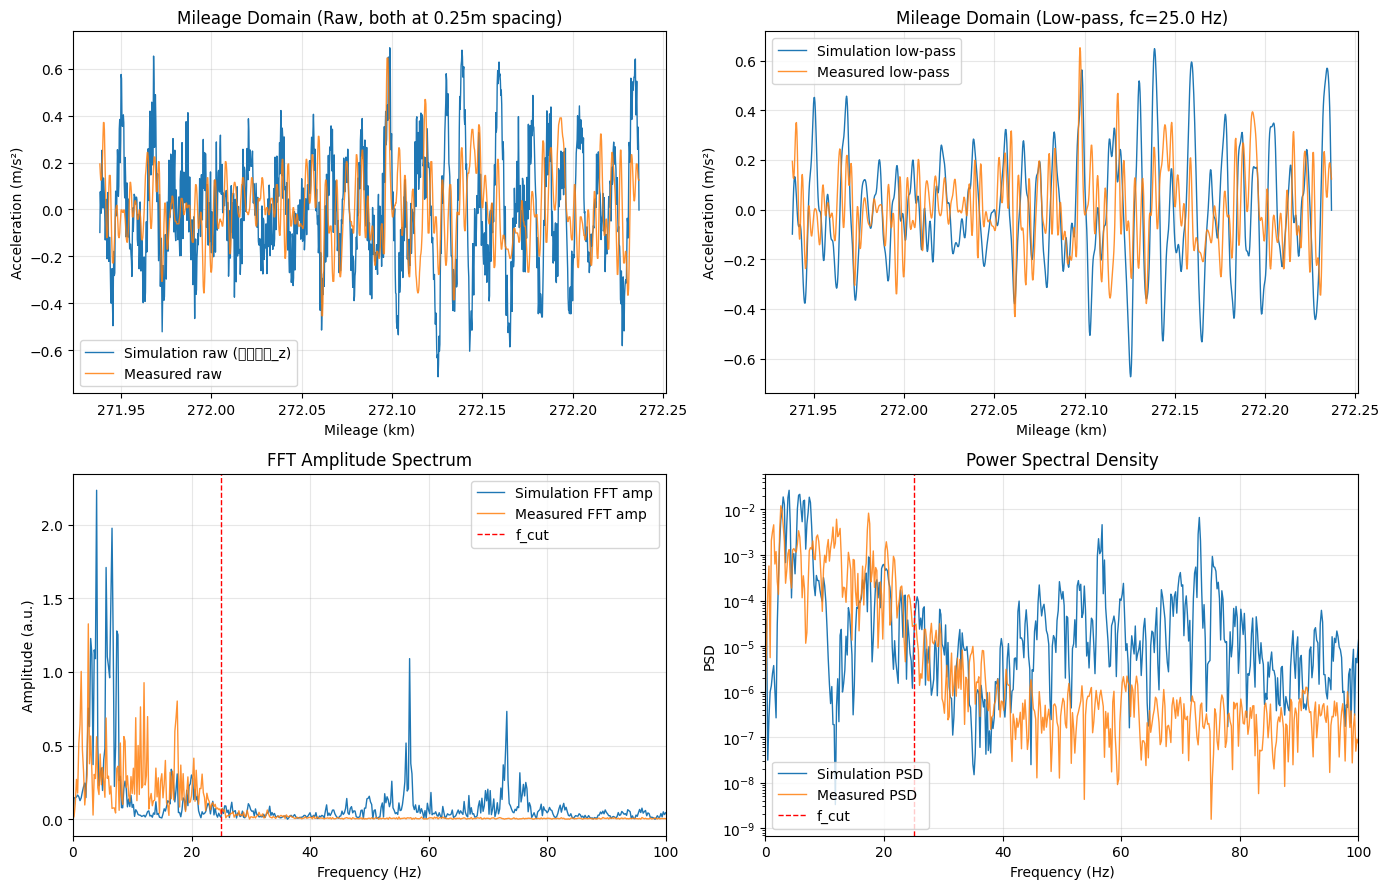

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

lc_start = float(jsion['start_mileage'][0])
# =========================
# 0) 参数设置
# =========================
lead_time_s = 2.0             # 前置无不平顺时长（与仿真设置一致）
search_window_m = 400.0        # 里程匹配搜索窗口：起点前后 ±50m
f_cut = 25.0                 # 低通截止频率(Hz)
meas_spacing_m = 0.25         # 动检里程采样间隔（m），每0.25m一个点

# =========================
# 1) 构造“从第2秒到末尾”的仿真片段，并按0.25m里程下采样
# =========================
dt = float(data['dt']) if 'dt' in data.files else float(np.mean(np.diff(t)))
fs_raw = 1.0 / dt
n_all = len(A_cal_y)
sim_time = np.arange(n_all) * dt

# 只保留第2秒到末尾
mask_t = sim_time >= lead_time_s
if np.count_nonzero(mask_t) < 10:
    raise ValueError('截取第2秒后的仿真数据点过少，请检查仿真时长与 dt。')

# 仿真里程轴（km）
v_kmh = float(v.iloc[0] if hasattr(v, 'iloc') else v[0])
v_mps = v_kmh / 3.6
sim_mileage_all = lc_start + v_kmh * sim_time / 3600.0
sim_mileage_cut = sim_mileage_all[mask_t]

# —— 关键新增：按“每0.25m”对仿真信号做里程域下采样（与动检一致） ——
spacing_km = meas_spacing_m / 1000.0
sim_mileage_ds = np.arange(sim_mileage_cut[0], sim_mileage_cut[-1] + 1e-12, spacing_km)
if len(sim_mileage_ds) < 10:
    raise ValueError('按0.25m下采样后的仿真点数过少，请检查数据范围。')

# 等效时间采样率（常速假设下：Δt = Δs / v）
dt_cmp = meas_spacing_m / v_mps
fs_cmp = 1.0 / dt_cmp

# 采用“构架1与构架2的均值”作为仿真对比通道，并插值到0.25m网格
sim_gou_mean_cut = 0.5 * (
    np.asarray(A_cal_gou1_z, dtype=float)[mask_t] +
    np.asarray(A_cal_gou2_z, dtype=float)[mask_t]
)
sim_candidates = {
    '构架均值_z': np.interp(sim_mileage_ds, sim_mileage_cut, sim_gou_mean_cut)
}

# =========================
# 2) 预处理动检数据（全里程范围，不先截段）
# =========================
m_meas_all = pd.to_numeric(dynamic_irr['里程'], errors='coerce').to_numpy(dtype=float)
az_meas_all_g = pd.to_numeric(dynamic_irr['垂向加速度(g)'], errors='coerce').to_numpy(dtype=float)

valid = np.isfinite(m_meas_all) & np.isfinite(az_meas_all_g)
m_meas_all = m_meas_all[valid]
az_meas_all_g = az_meas_all_g[valid]

order = np.argsort(m_meas_all)
m_meas_all = m_meas_all[order]
az_meas_all_g = az_meas_all_g[order]

m_unique, first_idx = np.unique(m_meas_all, return_index=True)
az_unique_g = az_meas_all_g[first_idx]

if len(m_unique) < 2:
    raise ValueError('动检数据有效里程点不足，无法进行匹配。')

# =========================
# 3) 在起点 ±50m 内搜索最佳里程对齐（在0.25m下采样后网格上比较）
# =========================
def metrics_basic(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = min(len(x), len(y))
    x = x[:n]
    y = y[:n]
    x0 = x - np.mean(x)
    y0 = y - np.mean(y)
    r = np.corrcoef(x0, y0)[0, 1]
    rmse = np.sqrt(np.mean((x0 - y0) ** 2))
    nrmse = rmse / (np.std(y0) + 1e-12)
    return r, rmse, nrmse

def lowpass_fft(x, dt_local, fc):
    x = np.asarray(x, dtype=float)
    f = np.fft.rfftfreq(len(x), d=dt_local)
    X = np.fft.rfft(x)
    X[f > fc] = 0.0
    return np.fft.irfft(X, n=len(x))

used_scipy = False
try:
    from scipy.signal import butter, filtfilt, welch

    def lowpass_butter(x, fs_local, fc, order=4):
        wn = fc / (0.5 * fs_local)
        wn = min(max(wn, 1e-6), 0.999999)
        b, a = butter(order, wn, btype='low')
        return filtfilt(b, a, x)

    used_scipy = True
except Exception:
    pass

sim_rel_km = sim_mileage_ds - sim_mileage_ds[0]
start_center = float(sim_mileage_ds[0])
start_candidates = m_unique[(m_unique >= start_center - search_window_m/1000.0) &
                            (m_unique <= start_center + search_window_m/1000.0)]

if len(start_candidates) == 0:
    raise ValueError('±50m搜索窗口内没有足够动检起点候选，请检查里程范围。')

# 为控制计算量，对候选起点下采样（最多约400个）
if len(start_candidates) > 400:
    step = int(np.ceil(len(start_candidates) / 400))
    start_candidates = start_candidates[::step]

best = None
scan_rows = []

for ch_name, sim_raw in sim_candidates.items():
    sim_raw = np.asarray(sim_raw, dtype=float)
    sim_raw = sim_raw - np.mean(sim_raw)

    if used_scipy:
        sim_lp_ch = lowpass_butter(sim_raw, fs_cmp, f_cut, order=4)
    else:
        sim_lp_ch = lowpass_fft(sim_raw, dt_cmp, f_cut)

    for s0 in start_candidates:
        meas_axis = s0 + sim_rel_km
        if meas_axis[0] < m_unique[0] or meas_axis[-1] > m_unique[-1]:
            continue

        meas_raw = np.interp(meas_axis, m_unique, az_unique_g) * 9.81
        meas_raw = meas_raw - np.mean(meas_raw)

        if used_scipy:
            meas_lp_ch = lowpass_butter(meas_raw, fs_cmp, f_cut, order=4)
        else:
            meas_lp_ch = lowpass_fft(meas_raw, dt_cmp, f_cut)

        r_raw, rmse_raw_tmp, nrmse_raw_tmp = metrics_basic(sim_raw, meas_raw)
        r_lp, rmse_lp_tmp, nrmse_lp_tmp = metrics_basic(sim_lp_ch, meas_lp_ch)

        # 主目标：低通相关系数最大；次目标：低通NRMSE最小
        score = r_lp - 0.15 * nrmse_lp_tmp

        row = {
            'channel': ch_name,
            'start_km': float(s0),
            'shift_m': float((s0 - start_center) * 1000.0),
            'corr_raw': float(r_raw),
            'nrmse_raw': float(nrmse_raw_tmp),
            'corr_lp': float(r_lp),
            'nrmse_lp': float(nrmse_lp_tmp),
            'score': float(score),
        }
        scan_rows.append(row)

        if (best is None) or (row['score'] > best['score']):
            best = dict(row)
            best['sim_raw'] = sim_raw
            best['meas_raw'] = meas_raw
            best['sim_lp'] = sim_lp_ch
            best['meas_lp'] = meas_lp_ch
            best['axis_km'] = meas_axis

if best is None:
    raise ValueError('未找到可用匹配结果，请检查动检里程覆盖范围。')

scan_df = pd.DataFrame(scan_rows).sort_values('score', ascending=False).reset_index(drop=True)
display(scan_df.head(12))

# 选出最佳结果，导出后续单元复用变量名
selected_channel = best['channel']
matched_start_km = best['start_km']
matched_shift_m = best['shift_m']

# 这里显式区分“降采样后的计算加速度”与其低通版本，便于频域比较使用
sim_ds_calc = best['sim_raw']   # 降采样后的仿真计算加速度
meas_ds = best['meas_raw']      # 与其对齐的降采样动检加速度
sim_lp = best['sim_lp']
meas_lp = best['meas_lp']
s_axis = best['axis_km']

r_raw, rmse_raw, nrmse_raw = metrics_basic(sim_ds_calc, meas_ds)
r_lp, rmse_lp, nrmse_lp = metrics_basic(sim_lp, meas_lp)

print(f"原始仿真采样: dt={dt:.6f}s, fs={fs_raw:.1f}Hz")
print(f"里程下采样后: Δs={meas_spacing_m:.2f}m, 等效dt={dt_cmp:.6f}s, 等效fs={fs_cmp:.1f}Hz")
print(f"已截取仿真时间段: t >= {lead_time_s:.1f}s, 原始点数={np.count_nonzero(mask_t)}, 下采样点数={len(sim_ds_calc)}")
print(f"仿真对比通道: {selected_channel}")
print(f"最佳动检起点: {matched_start_km:.6f} km (相对仿真起点偏移 {matched_shift_m:.1f} m)")
print(f"频域比较信号: 降采样后的仿真计算加速度(sim_ds_calc) vs 对齐后的动检加速度(meas_ds)")
print(f"Raw      : corr={r_raw:.4f}, RMSE={rmse_raw:.4f}, NRMSE={nrmse_raw:.4f}")
print(f"Low-pass : corr={r_lp:.4f}, RMSE={rmse_lp:.4f}, NRMSE={nrmse_lp:.4f}")

# =========================
# 4) 频域分析（基于里程下采样后的等效时间轴）
# =========================
def fft_power(x, dt_local):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    f = np.fft.rfftfreq(len(x), d=dt_local)
    X = np.fft.rfft(x)
    P = (np.abs(X) ** 2) / max(len(x), 1)
    return f, P

def high_freq_ratio(f, P, fc):
    total = np.sum(P)
    return np.nan if total <= 0 else np.sum(P[f >= fc]) / total

# 频域比较明确使用“降采样后的计算加速度”
f_sim, P_sim = fft_power(sim_ds_calc, dt_cmp)
f_mea, P_mea = fft_power(meas_ds, dt_cmp)
hf_ratio_sim = high_freq_ratio(f_sim, P_sim, f_cut)
hf_ratio_mea = high_freq_ratio(f_mea, P_mea, f_cut)

print(f"仿真信号 高频能量占比(>= {f_cut:.1f}Hz): {hf_ratio_sim:.2%}")
print(f"测量信号 高频能量占比(>= {f_cut:.1f}Hz): {hf_ratio_mea:.2%}")

# =========================
# 5) 绘图：时域 + FFT + PSD
# =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(s_axis, sim_ds_calc, lw=1.0, label=f'Simulation raw ({selected_channel})')
axes[0, 0].plot(s_axis, meas_ds, lw=1.0, label='Measured raw', alpha=0.85)
axes[0, 0].set_title('Mileage Domain (Raw, both at 0.25m spacing)')
axes[0, 0].set_xlabel('Mileage (km)')
axes[0, 0].set_ylabel('Acceleration (m/s²)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(s_axis, sim_lp, lw=1.0, label='Simulation low-pass')
axes[0, 1].plot(s_axis, meas_lp, lw=1.0, label='Measured low-pass', alpha=0.85)
axes[0, 1].set_title(f'Mileage Domain (Low-pass, fc={f_cut:.1f} Hz)')
axes[0, 1].set_xlabel('Mileage (km)')
axes[0, 1].set_ylabel('Acceleration (m/s²)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

amp_sim = np.sqrt(P_sim)
amp_mea = np.sqrt(P_mea)
axes[1, 0].plot(f_sim, amp_sim, lw=1.0, label='Simulation FFT amp')
axes[1, 0].plot(f_mea, amp_mea, lw=1.0, label='Measured FFT amp', alpha=0.85)
axes[1, 0].axvline(f_cut, color='r', ls='--', lw=1.0, label='f_cut')
axes[1, 0].set_xlim(0, min(100, fs_cmp/2))
axes[1, 0].set_title('FFT Amplitude Spectrum')
axes[1, 0].set_xlabel('Frequency (Hz)')
axes[1, 0].set_ylabel('Amplitude (a.u.)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

if used_scipy:
    nperseg = min(4096, len(sim_ds_calc))
    fw_s, psd_s = welch(sim_ds_calc, fs=fs_cmp, nperseg=nperseg)
    fw_m, psd_m = welch(meas_ds, fs=fs_cmp, nperseg=nperseg)
    axes[1, 1].semilogy(fw_s, psd_s + 1e-20, lw=1.0, label='Simulation PSD')
    axes[1, 1].semilogy(fw_m, psd_m + 1e-20, lw=1.0, label='Measured PSD', alpha=0.85)
else:
    axes[1, 1].semilogy(f_sim, P_sim + 1e-20, lw=1.0, label='Simulation PSD(FFT)')
    axes[1, 1].semilogy(f_mea, P_mea + 1e-20, lw=1.0, label='Measured PSD(FFT)', alpha=0.85)

axes[1, 1].axvline(f_cut, color='r', ls='--', lw=1.0, label='f_cut')
axes[1, 1].set_xlim(0, min(100, fs_cmp/2))
axes[1, 1].set_title('Power Spectral Density')
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].set_ylabel('PSD')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

,sim_channel,meas_channel,start_km,shift_m,corr_raw,nrmse_raw,corr_lp,nrmse_lp,score
0,轮对1轴心Z,实测左高低_mm,271.93625,-105.892164,0.708783,0.826348,0.710333,0.825040,0.586577
1,轮对1轴心Z,实测左高低_mm,271.93825,-103.892164,0.352227,1.212147,0.353910,1.211315,0.172212
2,轮对1轴心Z,实测左高低_mm,271.93425,-107.892164,0.315902,1.263900,0.317691,1.263178,0.128215
3,轮对1轴心Z,实测左高低_mm,272.40625,364.107836,0.296334,1.223337,0.297847,1.224507,0.114171
4,轮对1轴心Z,实测左高低_mm,272.40425,362.107836,0.295735,1.224717,0.297622,1.225438,0.113806
5,轮对1轴心Z,实测左高低_mm,272.21825,176.107836,0.269613,1.247397,0.270994,1.247552,0.083861
6,轮对1轴心Z,实测左高低_mm,272.14425,102.107836,0.243489,1.252231,0.244380,1.252467,0.056510
7,轮对1轴心Z,实测左高低_mm,271.86225,-179.892164,0.250632,1.353624,0.251628,1.354456,0.048460
8,轮对1轴心Z,实测左高低_mm,271.75825,-283.892164,0.259572,1.461441,0.260593,1.462886,0.041161
9,轮对1轴心Z,实测左高低_mm,272.20225,160.107836,0.216475,1.284744,0.217421,1.285248,0.024633


仿真动态不平顺通道: 轮对1轴心Z
实测动态不平顺通道: 实测左高低_mm
比较前处理: 前置截断 2.0s + 里程下采样 0.25m + 里程对齐搜索 ±400.0m
最佳实测起点: 271.936250 km (相对仿真起点偏移 -105.9 m)
Raw      : corr=0.7088, RMSE=0.000827 m, NRMSE=0.8263
Low-pass : corr=0.7103, RMSE=0.000824 m, NRMSE=0.8250


C:\Users\20991\AppData\Local\Temp\ipykernel_47872\1559815879.py:237: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20991\AppData\Local\Temp\ipykernel_47872\1559815879.py:237: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20991\AppData\Local\Temp\ipykernel_47872\1559815879.py:237: UserWarning: Glyph 36724 (\N{CJK UNIFIED IDEOGRAPH-8F74}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20991\AppData\Local\Temp\ipykernel_47872\1559815879.py:237: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20991\AppData\Local\Temp\ipykernel_47872\1559815879.py:237: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20991\AppData\Local\Temp\ipykernel_47872\1559815879.py:237: UserWarning: Glyph 27

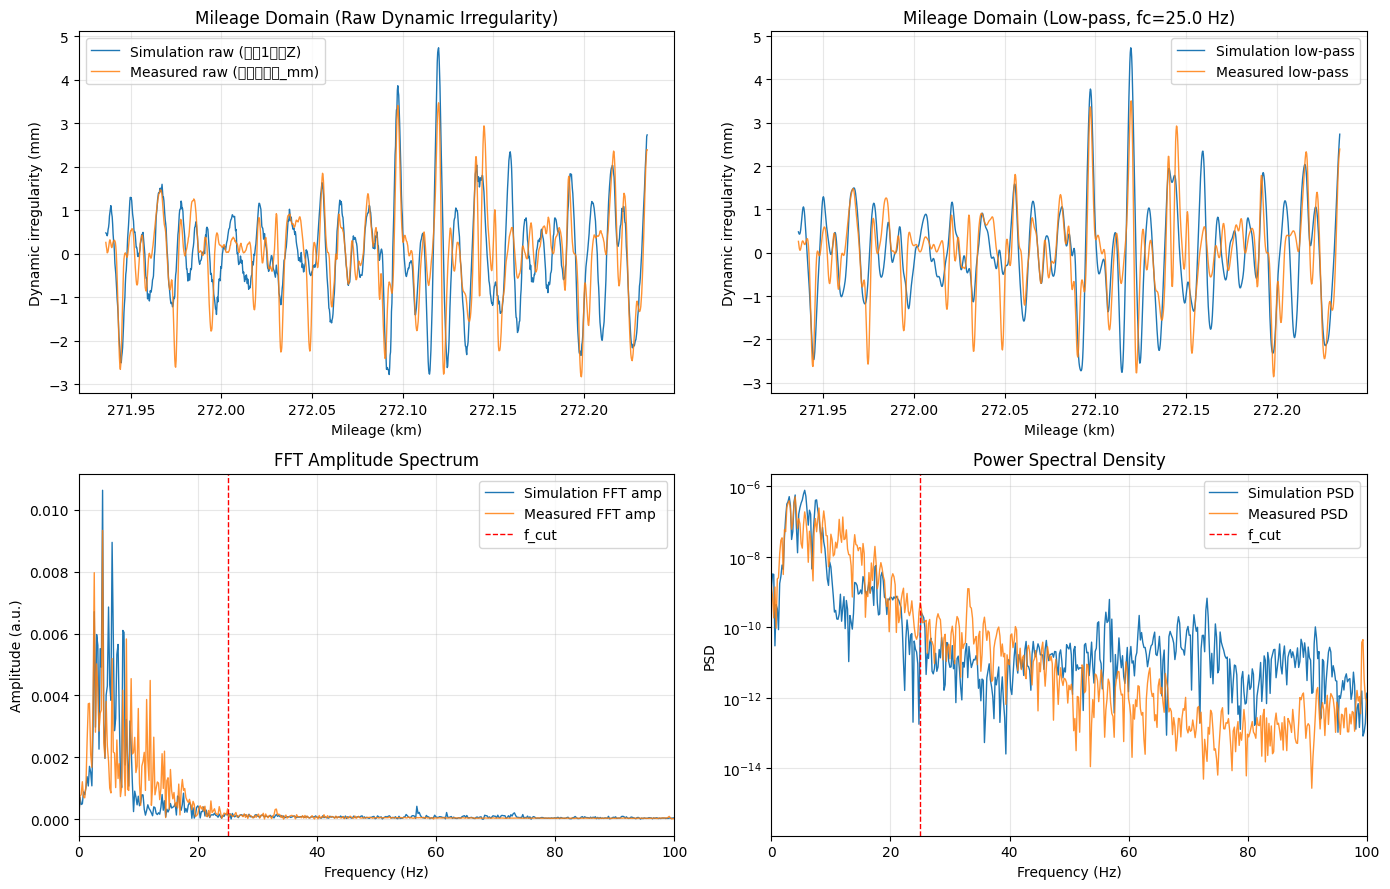

In [ ]:
# =========================
# 轮对动态不平顺 vs 实测动态不平顺：对齐 + 下采样 + 比较
# 参考上一单元格的处理流程，但此处比较对象改为“位移型动态不平顺”
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 0) 明确输入 ----------
sim_channel_name_dyn = '轮对1轴心Z'      # 可改为：轮对2轴心Z / 轮对3轴心Z / 轮对4轴心Z
meas_channel_name_dyn = '实测左高低_mm'   # 可改为：实测右高低_mm
lead_time_s_dyn = 2.0
search_window_m_dyn = 400.0
f_cut_dyn = 25.0
meas_spacing_m_dyn = 0.25

if sim_channel_name_dyn not in sim_dynamic_irregularity_candidates:
    raise KeyError(f'仿真候选通道不存在: {sim_channel_name_dyn}')
if meas_channel_name_dyn not in measured_dynamic_irregularity_candidates:
    raise KeyError(f'实测候选通道不存在: {meas_channel_name_dyn}')
if not meas_channel_name_dyn.endswith('_mm'):
    raise ValueError('本单元格当前用于位移型动态不平顺比较，请选择 实测左高低_mm 或 实测右高低_mm。')

sim_signal_all = np.asarray(sim_dynamic_irregularity_candidates[sim_channel_name_dyn], dtype=float)
meas_signal_all = np.asarray(measured_dynamic_irregularity_candidates[meas_channel_name_dyn], dtype=float) / 1000.0  # mm -> m

# ---------- 1) 仿真信号：截去前置无不平顺，并按 0.25m 下采样 ----------
lc_start_dyn = float(jsion['start_mileage'][0])
v_kmh_dyn = float(v.iloc[0] if hasattr(v, 'iloc') else v[0])
v_mps_dyn = v_kmh_dyn / 3.6

sim_time_dyn = np.arange(len(sim_signal_all)) * dt
mask_t_dyn = sim_time_dyn >= lead_time_s_dyn
if np.count_nonzero(mask_t_dyn) < 10:
    raise ValueError('截取前置无不平顺后，仿真点数过少。')

sim_mileage_all_dyn = lc_start_dyn + v_kmh_dyn * sim_time_dyn / 3600.0
sim_mileage_cut_dyn = sim_mileage_all_dyn[mask_t_dyn]
sim_signal_cut_dyn = sim_signal_all[mask_t_dyn]

spacing_km_dyn = meas_spacing_m_dyn / 1000.0
sim_mileage_ds_dyn = np.arange(sim_mileage_cut_dyn[0], sim_mileage_cut_dyn[-1] + 1e-12, spacing_km_dyn)
if len(sim_mileage_ds_dyn) < 10:
    raise ValueError('动态不平顺比较中，仿真下采样点数过少。')

sim_ds_dyn = np.interp(sim_mileage_ds_dyn, sim_mileage_cut_dyn, sim_signal_cut_dyn)
sim_rel_km_dyn = sim_mileage_ds_dyn - sim_mileage_ds_dyn[0]

dt_cmp_dyn = meas_spacing_m_dyn / v_mps_dyn
fs_cmp_dyn = 1.0 / dt_cmp_dyn

# ---------- 2) 实测信号：里程排序、去重 ----------
meas_mileage_dyn = np.asarray(meas_mileage, dtype=float)
valid_dyn = np.isfinite(meas_mileage_dyn) & np.isfinite(meas_signal_all)
meas_mileage_dyn = meas_mileage_dyn[valid_dyn]
meas_signal_all = meas_signal_all[valid_dyn]

order_dyn = np.argsort(meas_mileage_dyn)
meas_mileage_dyn = meas_mileage_dyn[order_dyn]
meas_signal_all = meas_signal_all[order_dyn]

meas_mileage_unique_dyn, first_idx_dyn = np.unique(meas_mileage_dyn, return_index=True)
meas_signal_unique_dyn = meas_signal_all[first_idx_dyn]
if len(meas_mileage_unique_dyn) < 2:
    raise ValueError('实测动态不平顺有效里程点不足，无法比较。')

# ---------- 3) 工具函数 ----------
def metrics_basic_dyn(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = min(len(x), len(y))
    x = x[:n]
    y = y[:n]
    x0 = x - np.mean(x)
    y0 = y - np.mean(y)
    r = np.corrcoef(x0, y0)[0, 1]
    rmse = np.sqrt(np.mean((x0 - y0) ** 2))
    nrmse = rmse / (np.std(y0) + 1e-12)
    return r, rmse, nrmse

def lowpass_fft_dyn(x, dt_local, fc):
    x = np.asarray(x, dtype=float)
    f = np.fft.rfftfreq(len(x), d=dt_local)
    Xf = np.fft.rfft(x)
    Xf[f > fc] = 0.0
    return np.fft.irfft(Xf, n=len(x))

def fft_power_dyn(x, dt_local):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    f = np.fft.rfftfreq(len(x), d=dt_local)
    Xf = np.fft.rfft(x)
    P = (np.abs(Xf) ** 2) / max(len(x), 1)
    return f, P

used_scipy_dyn = False
try:
    from scipy.signal import butter, filtfilt, welch

    def lowpass_butter_dyn(x, fs_local, fc, order=4):
        wn = fc / (0.5 * fs_local)
        wn = min(max(wn, 1e-6), 0.999999)
        b, a = butter(order, wn, btype='low')
        return filtfilt(b, a, x)

    used_scipy_dyn = True
except Exception:
    pass

# ---------- 4) 里程对齐搜索 ----------
start_center_dyn = float(sim_mileage_ds_dyn[0])
start_candidates_dyn = meas_mileage_unique_dyn[
    (meas_mileage_unique_dyn >= start_center_dyn - search_window_m_dyn / 1000.0) &
    (meas_mileage_unique_dyn <= start_center_dyn + search_window_m_dyn / 1000.0)
]
if len(start_candidates_dyn) == 0:
    raise ValueError('动态不平顺比较时，搜索窗口内没有可用实测起点候选。')
if len(start_candidates_dyn) > 400:
    step_dyn = int(np.ceil(len(start_candidates_dyn) / 400))
    start_candidates_dyn = start_candidates_dyn[::step_dyn]

best_dyn = None
scan_rows_dyn = []

sim_raw_dyn = sim_ds_dyn - np.mean(sim_ds_dyn)
sim_lp_dyn = lowpass_butter_dyn(sim_raw_dyn, fs_cmp_dyn, f_cut_dyn, order=4) if used_scipy_dyn else lowpass_fft_dyn(sim_raw_dyn, dt_cmp_dyn, f_cut_dyn)

for s0_dyn in start_candidates_dyn:
    meas_axis_dyn = s0_dyn + sim_rel_km_dyn
    if meas_axis_dyn[0] < meas_mileage_unique_dyn[0] or meas_axis_dyn[-1] > meas_mileage_unique_dyn[-1]:
        continue

    meas_raw_dyn = np.interp(meas_axis_dyn, meas_mileage_unique_dyn, meas_signal_unique_dyn)
    meas_raw_dyn = meas_raw_dyn - np.mean(meas_raw_dyn)
    meas_lp_dyn = lowpass_butter_dyn(meas_raw_dyn, fs_cmp_dyn, f_cut_dyn, order=4) if used_scipy_dyn else lowpass_fft_dyn(meas_raw_dyn, dt_cmp_dyn, f_cut_dyn)

    r_raw_dyn, rmse_raw_dyn, nrmse_raw_dyn = metrics_basic_dyn(sim_raw_dyn, meas_raw_dyn)
    r_lp_dyn, rmse_lp_dyn, nrmse_lp_dyn = metrics_basic_dyn(sim_lp_dyn, meas_lp_dyn)
    score_dyn = r_lp_dyn - 0.15 * nrmse_lp_dyn

    row_dyn = {
        'sim_channel': sim_channel_name_dyn,
        'meas_channel': meas_channel_name_dyn,
        'start_km': float(s0_dyn),
        'shift_m': float((s0_dyn - start_center_dyn) * 1000.0),
        'corr_raw': float(r_raw_dyn),
        'nrmse_raw': float(nrmse_raw_dyn),
        'corr_lp': float(r_lp_dyn),
        'nrmse_lp': float(nrmse_lp_dyn),
        'score': float(score_dyn),
    }
    scan_rows_dyn.append(row_dyn)

    if (best_dyn is None) or (row_dyn['score'] > best_dyn['score']):
        best_dyn = dict(row_dyn)
        best_dyn['sim_raw'] = sim_raw_dyn
        best_dyn['meas_raw'] = meas_raw_dyn
        best_dyn['sim_lp'] = sim_lp_dyn
        best_dyn['meas_lp'] = meas_lp_dyn
        best_dyn['axis_km'] = meas_axis_dyn

if best_dyn is None:
    raise ValueError('动态不平顺比较未找到可用匹配结果。')

scan_df_dyn = pd.DataFrame(scan_rows_dyn).sort_values('score', ascending=False).reset_index(drop=True)
display(scan_df_dyn.head(12))

sim_dyn_cmp = best_dyn['sim_raw']
meas_dyn_cmp = best_dyn['meas_raw']
sim_dyn_lp = best_dyn['sim_lp']
meas_dyn_lp = best_dyn['meas_lp']
s_axis_dyn = best_dyn['axis_km']

r_raw_dyn, rmse_raw_dyn, nrmse_raw_dyn = metrics_basic_dyn(sim_dyn_cmp, meas_dyn_cmp)
r_lp_dyn, rmse_lp_dyn, nrmse_lp_dyn = metrics_basic_dyn(sim_dyn_lp, meas_dyn_lp)

print(f'仿真动态不平顺通道: {sim_channel_name_dyn}')
print(f'实测动态不平顺通道: {meas_channel_name_dyn}')
print(f'比较前处理: 前置截断 {lead_time_s_dyn:.1f}s + 里程下采样 {meas_spacing_m_dyn:.2f}m + 里程对齐搜索 ±{search_window_m_dyn:.1f}m')
print(f'最佳实测起点: {best_dyn["start_km"]:.6f} km (相对仿真起点偏移 {best_dyn["shift_m"]:.1f} m)')
print(f'Raw      : corr={r_raw_dyn:.4f}, RMSE={rmse_raw_dyn:.6f} m, NRMSE={nrmse_raw_dyn:.4f}')
print(f'Low-pass : corr={r_lp_dyn:.4f}, RMSE={rmse_lp_dyn:.6f} m, NRMSE={nrmse_lp_dyn:.4f}')

# ---------- 5) 频域比较 ----------
f_sim_dyn, P_sim_dyn = fft_power_dyn(sim_dyn_cmp, dt_cmp_dyn)
f_mea_dyn, P_mea_dyn = fft_power_dyn(meas_dyn_cmp, dt_cmp_dyn)
amp_sim_dyn = np.sqrt(P_sim_dyn)
amp_mea_dyn = np.sqrt(P_mea_dyn)

# ---------- 6) 绘图 ----------
fig_dyn, axes_dyn = plt.subplots(2, 2, figsize=(14, 9))

axes_dyn[0, 0].plot(s_axis_dyn, sim_dyn_cmp * 1000.0, lw=1.0, label=f'Simulation raw ({sim_channel_name_dyn})')
axes_dyn[0, 0].plot(s_axis_dyn, meas_dyn_cmp * 1000.0, lw=1.0, label=f'Measured raw ({meas_channel_name_dyn})', alpha=0.85)
axes_dyn[0, 0].set_title('Mileage Domain (Raw Dynamic Irregularity)')
axes_dyn[0, 0].set_xlabel('Mileage (km)')
axes_dyn[0, 0].set_ylabel('Dynamic irregularity (mm)')
axes_dyn[0, 0].grid(True, alpha=0.3)
axes_dyn[0, 0].legend()

axes_dyn[0, 1].plot(s_axis_dyn, sim_dyn_lp * 1000.0, lw=1.0, label='Simulation low-pass')
axes_dyn[0, 1].plot(s_axis_dyn, meas_dyn_lp * 1000.0, lw=1.0, label='Measured low-pass', alpha=0.85)
axes_dyn[0, 1].set_title(f'Mileage Domain (Low-pass, fc={f_cut_dyn:.1f} Hz)')
axes_dyn[0, 1].set_xlabel('Mileage (km)')
axes_dyn[0, 1].set_ylabel('Dynamic irregularity (mm)')
axes_dyn[0, 1].grid(True, alpha=0.3)
axes_dyn[0, 1].legend()

axes_dyn[1, 0].plot(f_sim_dyn, amp_sim_dyn, lw=1.0, label='Simulation FFT amp')
axes_dyn[1, 0].plot(f_mea_dyn, amp_mea_dyn, lw=1.0, label='Measured FFT amp', alpha=0.85)
axes_dyn[1, 0].axvline(f_cut_dyn, color='r', ls='--', lw=1.0, label='f_cut')
axes_dyn[1, 0].set_xlim(0, min(100, fs_cmp_dyn / 2))
axes_dyn[1, 0].set_title('FFT Amplitude Spectrum')
axes_dyn[1, 0].set_xlabel('Frequency (Hz)')
axes_dyn[1, 0].set_ylabel('Amplitude (a.u.)')
axes_dyn[1, 0].grid(True, alpha=0.3)
axes_dyn[1, 0].legend()

if used_scipy_dyn:
    nperseg_dyn = min(4096, len(sim_dyn_cmp))
    fw_s_dyn, psd_s_dyn = welch(sim_dyn_cmp, fs=fs_cmp_dyn, nperseg=nperseg_dyn)
    fw_m_dyn, psd_m_dyn = welch(meas_dyn_cmp, fs=fs_cmp_dyn, nperseg=nperseg_dyn)
    axes_dyn[1, 1].semilogy(fw_s_dyn, psd_s_dyn + 1e-20, lw=1.0, label='Simulation PSD')
    axes_dyn[1, 1].semilogy(fw_m_dyn, psd_m_dyn + 1e-20, lw=1.0, label='Measured PSD', alpha=0.85)
else:
    axes_dyn[1, 1].semilogy(f_sim_dyn, P_sim_dyn + 1e-20, lw=1.0, label='Simulation PSD(FFT)')
    axes_dyn[1, 1].semilogy(f_mea_dyn, P_mea_dyn + 1e-20, lw=1.0, label='Measured PSD(FFT)', alpha=0.85)

axes_dyn[1, 1].axvline(f_cut_dyn, color='r', ls='--', lw=1.0, label='f_cut')
axes_dyn[1, 1].set_xlim(0, min(100, fs_cmp_dyn / 2))
axes_dyn[1, 1].set_title('Power Spectral Density')
axes_dyn[1, 1].set_xlabel('Frequency (Hz)')
axes_dyn[1, 1].set_ylabel('PSD')
axes_dyn[1, 1].grid(True, alpha=0.3)
axes_dyn[1, 1].legend()

plt.tight_layout()
plt.show()